In [2]:
import os
import logging

import csv
import numpy as np
import datetime
import xarray as xr


import matplotlib.pyplot as plt


In [3]:
cruise_id = 'sofe'
float_ids = ['f10761', 'f10762', 'f10763']

In [4]:
repodir = os.path.dirname(os.path.abspath(''))
print('Repository: ', repodir)
datadir = os.path.join(repodir, 'data')
figsdir = os.path.join(repodir, 'figs')

# dec_filedir = os.path.join(datadir, cruise_id, float_id, 'proc', 'dec')
# vel_filedir = os.path.join(datadir, cruise_id, float_id, 'proc', 'vel')


Repository:  /home/jjmeijer/Repos/ema-seir-pf


In [5]:
filedirs = {}
for float_id in float_ids:
    filedirs[float_id] = {
        'dec': os.path.join(datadir, cruise_id, float_id, 'proc', 'dec'),
        'vel': os.path.join(datadir, cruise_id, float_id, 'proc', 'vel')
    }

In [6]:
# !! REMINDER START FROM HERE, 3 INSTEAD OF 1 FLOAT, THEREFORE FILES HAVE TO BE LOAD PER FLOAT_ID LIKE THE EXAMPLE BELOW
# # read all vitals files
# vitals = {}
# for float_id in float_ids:
#     vitals[float_id] = {}
#     files = [os.path.join(filedirs(float_id)['dec'], file) for file in sorted(os.listdir(filedirs(float_id)['dec'])) if file.endswith('vitals_log.csv')]
#     for filename in files:
#         profile_no = os.path.basename(filename).split('.')[1]
#         vitals[float_id][profile_no] = read_vitals(filename)

## Read CSV files

In [7]:
# read all science files
ctd_descent, ctd_ascent = {}, {}
gps_surface, gps_ascent, gps_descent = {}, {}, {}

# float_id = float_ids[0]
for float_id in float_ids:

    files = [os.path.join(filedirs[float_id]['dec'], file) for file in sorted(os.listdir(filedirs[float_id]['dec'])) if file.endswith('science_log.csv')]

    # for filename in files:
    #     read_science_csv(filename)
    
    # def read_science_csv():

    ctd_descent[float_id], ctd_ascent[float_id] = {}, {}
    gps_surface[float_id], gps_ascent[float_id], gps_descent[float_id] = {}, {}, {}

    for filename in files:
        profile_no = os.path.basename(filename).split('.')[1]
        # print(profile_no, filename)
    
        # setup surface data structure
        gps_surface[float_id][profile_no] = {'TIMESTAMP': [], 'LAT': [], 'LON': [], 'NSAT': []}
        
        # setup descent data structures
        ctd_descent[float_id][profile_no] = {'time': np.array([]), 'p': np.array([]), 'T': np.array([]), 'S': np.array([])}
        gps_descent[float_id][profile_no] = {'TIMESTAMP': [], 'LAT': [], 'LON': [], 'NSAT': []}
    
        # setup ascent data structures
        ctd_ascent[float_id][profile_no] = {'time': np.array([]), 'p': np.array([]), 'T': np.array([]), 'S': np.array([])}
        gps_ascent[float_id][profile_no] = {'TIMESTAMP': [], 'LAT': [], 'LON': [], 'NSAT': []}
    
        # assume starting with a descent until the ascent message is found
        process_as_ascent_data = False
        found_descent_start = False
        found_ascent_start = False
    
        with open(filename, newline='') as csvfile:
        
            reader = csv.DictReader(csvfile, fieldnames=['ID', 'TIMESTAMP'], restkey='DATA')
            for row in reader:
    
                # pick up mission status
                if row['ID'] == 'Message':
                    if row['DATA'][0] == 'ASCENT':
                        process_as_ascent_data = True
                        found_ascent_start = True
                    elif row['DATA'][0] == 'Park Descent Mission':
                        found_descent_start = True
    
                # process CTD PTS data
                elif row['ID'] == 'CTD_PTS' or row['ID'] == "LGR_PTSCI":
    
                    timestamp = datetime.datetime.strptime(row['TIMESTAMP'],'%Y%m%dT%H%M%S')
                    pressure = float(row['DATA'][0])
                    temperature = float(row['DATA'][1])
                    salinity = float(row['DATA'][2])
                    
                    if process_as_ascent_data:
                        ctd_ascent[float_id][profile_no]['time'] = np.append(ctd_ascent[float_id][profile_no]['time'], timestamp)
                        ctd_ascent[float_id][profile_no]['p'] = np.append(ctd_ascent[float_id][profile_no]['p'], pressure)
                        ctd_ascent[float_id][profile_no]['T'] = np.append(ctd_ascent[float_id][profile_no]['T'], temperature)
                        ctd_ascent[float_id][profile_no]['S'] = np.append(ctd_ascent[float_id][profile_no]['S'], salinity)
                    else:
                        ctd_descent[float_id][profile_no]['time'] = np.append(ctd_descent[float_id][profile_no]['time'], timestamp)
                        ctd_descent[float_id][profile_no]['p'] = np.append(ctd_descent[float_id][profile_no]['p'], pressure)
                        ctd_descent[float_id][profile_no]['T'] = np.append(ctd_descent[float_id][profile_no]['T'], temperature)
                        ctd_descent[float_id][profile_no]['S'] = np.append(ctd_descent[float_id][profile_no]['S'], salinity)
                        
                # process GPS data
                elif row['ID'] == 'GPS':
                    
                    if process_as_ascent_data:
                        gps_data_dict = gps_ascent
                    else:
                        gps_data_dict = gps_descent
    
                    timestamp = datetime.datetime.strptime(row['TIMESTAMP'],'%Y%m%dT%H%M%S')
                    lat = float(row['DATA'][0])
                    lon = float(row['DATA'][1])
                    nsat = float(row['DATA'][2])
                    
                    # skip bad gps values
                    if np.isfinite(lat) and np.isfinite(lon) and np.isfinite(nsat):
                        gps_data_dict[float_id][profile_no]['TIMESTAMP'] = np.append(gps_data_dict[float_id][profile_no]['TIMESTAMP'], timestamp)
                        gps_data_dict[float_id][profile_no]['LAT'] = np.append(gps_data_dict[float_id][profile_no]['LAT'], lat)
                        gps_data_dict[float_id][profile_no]['LON'] = np.append(gps_data_dict[float_id][profile_no]['LON'], lon )
                        gps_data_dict[float_id][profile_no]['NSAT'] = np.append(gps_data_dict[float_id][profile_no]['NSAT'], nsat)
    
        # end of collecting data, begin processing
        if len(ctd_descent[float_id][profile_no]['time']) == 0 or len(ctd_descent[float_id][profile_no]['p']) == 0 or len(ctd_descent[float_id][profile_no]['T']) == 0 or len(ctd_descent[float_id][profile_no]['S']) == 0:
            ctd_descent[float_id].pop(profile_no)
            logging.error("missing CTD data in descent profile %d, removed profile %s from dict" % (int(profile_no), profile_no))
            continue
        if len(ctd_ascent[float_id][profile_no]['time']) == 0 or len(ctd_ascent[float_id][profile_no]['p']) == 0 or len(ctd_ascent[float_id][profile_no]['T']) == 0 or len(ctd_ascent[float_id][profile_no]['S']) == 0:
            ctd_ascent[float_id].pop(profile_no)
            logging.error("missing CTD data in ascent profile %d, removed profile %s from dict" % (int(profile_no), profile_no))
            continue
        if len(gps_descent[float_id][profile_no]['TIMESTAMP']) == 0:
            logging.error("no descent GPS data found in profile %d" % int(profile_no))
            continue
        elif len(gps_ascent[float_id][profile_no]['TIMESTAMP']) == 0:
            logging.error("no ascent GPS data found in profile %d" % int(profile_no))
            continue
        elif not found_descent_start:
            logging.error("descent not found in science log in profile %d" % int(profile_no))
            continue
        elif not found_ascent_start:
            logging.error("ascent not found in science log in profile %d" % int(profile_no))
            continue
    
        # save the initial gps at start of previous surfacing for surface trift
        gps_surface[float_id][profile_no]['TIMESTAMP'] = gps_descent[float_id][profile_no]['TIMESTAMP'][0]
        gps_surface[float_id][profile_no]['LAT'] = gps_descent[float_id][profile_no]['LAT'][0]
        gps_surface[float_id][profile_no]['LON'] = gps_descent[float_id][profile_no]['LON'][0]
        gps_surface[float_id][profile_no]['NSAT'] = gps_descent[float_id][profile_no]['NSAT'][0]


ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in ascent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in ascent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in ascent profile 0, removed profile 000 from dict


In [8]:
for float_id in float_ids:

    # make a set of stations, each station has a descent and an ascent profile
    stations = np.unique([int(pf_no) for pf_no in list(ctd_descent[float_id].keys()) + list(ctd_ascent[float_id].keys())])
    stations = np.array([x for x in stations for _ in range(2)])
    
    # define dimensions of dataset/ arrays
    profiles = np.array([ipf for ipf in range(len(stations))])
    nlevels = max(max([(len(d_values['time']), len(a_values['time'])) 
                       for d_values, a_values in zip(ctd_descent[float_id].values(), ctd_ascent[float_id].values())]))
    levels = np.linspace(0, nlevels, nlevels+1)
    
    # initialise empty masked arrays
    shape = (len(profiles), len(levels))
    ctd_array = {
        'time': np.ma.masked_all(shape, dtype='datetime64[s]'),
        'p': np.ma.masked_all(shape),
        'T': np.ma.masked_all(shape),
        'S': np.ma.masked_all(shape),
    }
    gps_array = {
        'lon': np.ma.masked_all(len(profiles)),
        'lat': np.ma.masked_all(len(profiles)),
    }
    
    # make square arrays from data in dictionary
    i_descent, i_ascent = 0, 1
    for (pf_no_desc, pf_data_desc), (pf_no_asc, pf_data_asc) in zip(ctd_descent[float_id].items(), ctd_ascent[float_id].items()):
        
        # processing descent ctd data
        ctd_array['time'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['time']
        ctd_array['p'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['p']
        ctd_array['T'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['T']
        ctd_array['S'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['S']
    
        # processing ascent ctd data
        ctd_array['time'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['time'])
        ctd_array['p'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['p'])
        ctd_array['T'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['T'])
        ctd_array['S'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['S'])
        
        # processing gps data
        try:
            gps_array['lon'][i_descent] = gps_descent[float_id][pf_no_desc]['LON'][-1]
            gps_array['lat'][i_descent] = gps_descent[float_id][pf_no_desc]['LAT'][-1]
        except IndexError:
            print('no GPS coordinates in descent profile %s' %pf_no_desc)
            # processing gps data
        try:
            gps_array['lon'][i_ascent] = gps_ascent[float_id][pf_no_asc]['LON'][0]
            gps_array['lat'][i_ascent] = gps_ascent[float_id][pf_no_asc]['LAT'][0]
        except IndexError:
            print('no GPS coordinates in ascent profile %s' %pf_no_asc)
        
        i_descent += 2
        i_ascent += 2
    
    # create dimensions and coordinates of Dataset
    coords = dict(
        station=('profile', stations),
        vertical=('level', levels),
        longitude=('longitude', gps_array['lon']),
        latitude=('latitude', gps_array['lat']),
    )
    
    # link CTD data to dimensions and coordinates
    data_vars = dict(
        time=(['profile', 'level'], ctd_array['time']),
        p=(['profile', 'level'], ctd_array['p']),
        T=(['profile', 'level'], ctd_array['T']),
        S=(['profile', 'level'], ctd_array['S']),
    )
    
    # store in xarray Dataset
    ctd = xr.Dataset(data_vars=data_vars, coords=coords)
    
    # # TODO: add meta data and attributes
    
    # # save to netcdf file
    ctd.to_netcdf(os.path.join(datadir, cruise_id, float_id, 'ctd_data_raw.nc'))
    ctd.close()

/tmp/ipykernel_59142/89669032.py:75: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ctd = xr.Dataset(data_vars=data_vars, coords=coords)
/tmp/ipykernel_59142/89669032.py:75: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to

In [9]:
for float_id in float_ids:

    filename = os.path.join(datadir, cruise_id, float_id, 'ctd_data_raw.nc')
    ctd = xr.open_dataset(filename)
    
    # make pressure coordinate
    dp = 2
    max_pressure = max([np.append(d_values['p'], a_values['p']).max()
                       for d_values, a_values in zip(ctd_descent[float_id].values(), ctd_ascent[float_id].values())])
    max_pressure = np.ceil(max_pressure / 2.) * 2
    pressure_coord = np.linspace(0, max_pressure, int(max_pressure / dp) + 1)
    
    def interp_profile(var, press):
        var_interp = np.interp(pressure_coord, press, var)
        finite_vals = var_interp[np.isfinite(var_interp)]
        if finite_vals.size == 0 or np.all(finite_vals == finite_vals[0]):
            return np.full_like(pressure_coord, np.nan, dtype=var.dtype)
        return np.interp(pressure_coord, press, var)
    
    temperature_interp = xr.apply_ufunc(
        interp_profile,
        ctd['T'],
        ctd['p'],
        input_core_dims=[['level'], ['level']],
        output_core_dims=[['pressure']],
        vectorize=True,
        dask='parallelized' if ctd['T'].chunks else False,
        output_dtypes=[ctd['T'].dtype]
    )
    
    salinity_interp = xr.apply_ufunc(
        interp_profile,
        ctd['S'],
        ctd['p'],
        input_core_dims=[['level'], ['level']],
        output_core_dims=[['pressure']],
        vectorize=True,
        dask='parallelized' if ctd['S'].chunks else False,
        output_dtypes=[ctd['T'].dtype]
    )
    
    # create dimensions and coordinates of Dataset
    # times = []
    # for ipf in range(len(ctd.station)):
    #     time = ctd.isel(profile=ipf).time.values[::2]
    #     finite = np.isfinite(time)
    #     if time[finite].size > 0:
    #         times.append(time[finite][0])
    #     else:
    #         times.append(np.nan)
    coords = dict(
        # time=('profile', times),
        station=('profile', ctd.station.values),
        pressure=('pressure', pressure_coord),
        longitude=('longitude', ctd.longitude.values),
        latitude=('latitude', ctd.latitude.values),
    )
    
    # link CTD data to dimensions and coordinates
    data_vars = dict(
        T=(['profile', 'pressure'], temperature_interp.values),
        S=(['profile', 'pressure'], salinity_interp.values),
    )
    
    # store in xarray Dataset
    ctd_interp = xr.Dataset(data_vars=data_vars, coords=coords)
    
    ctd_interp.to_netcdf(os.path.join(datadir, cruise_id, float_id, 'ctd_data_pgrid.nc'))
    ctd_interp.close()

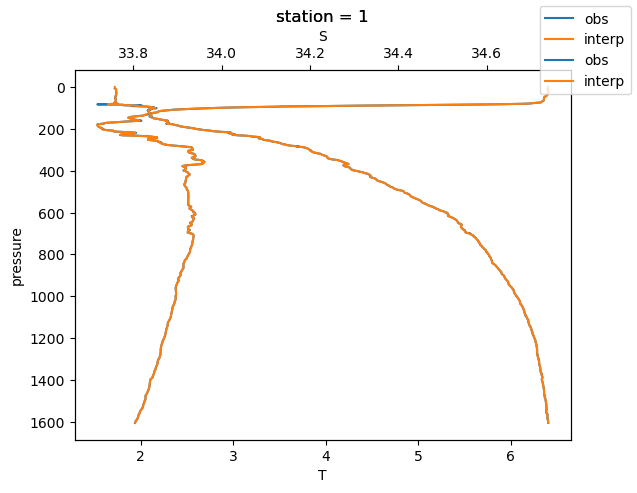

In [10]:
profile=2

fig, ax =plt.subplots()

# temperature 
ax.plot(ctd.isel(profile=profile).T, ctd.isel(profile=profile).p, label='obs')
ctd_interp.isel(profile=profile).T.plot(ax=ax, y='pressure', label='interp')

# salinity
ax2 = ax.twiny()
ax2.plot(ctd.isel(profile=profile).S, ctd.isel(profile=profile).p, label='obs')
ctd_interp.isel(profile=profile).S.plot(ax=ax2, y='pressure', label='interp')

ax.invert_yaxis()
fig.legend()

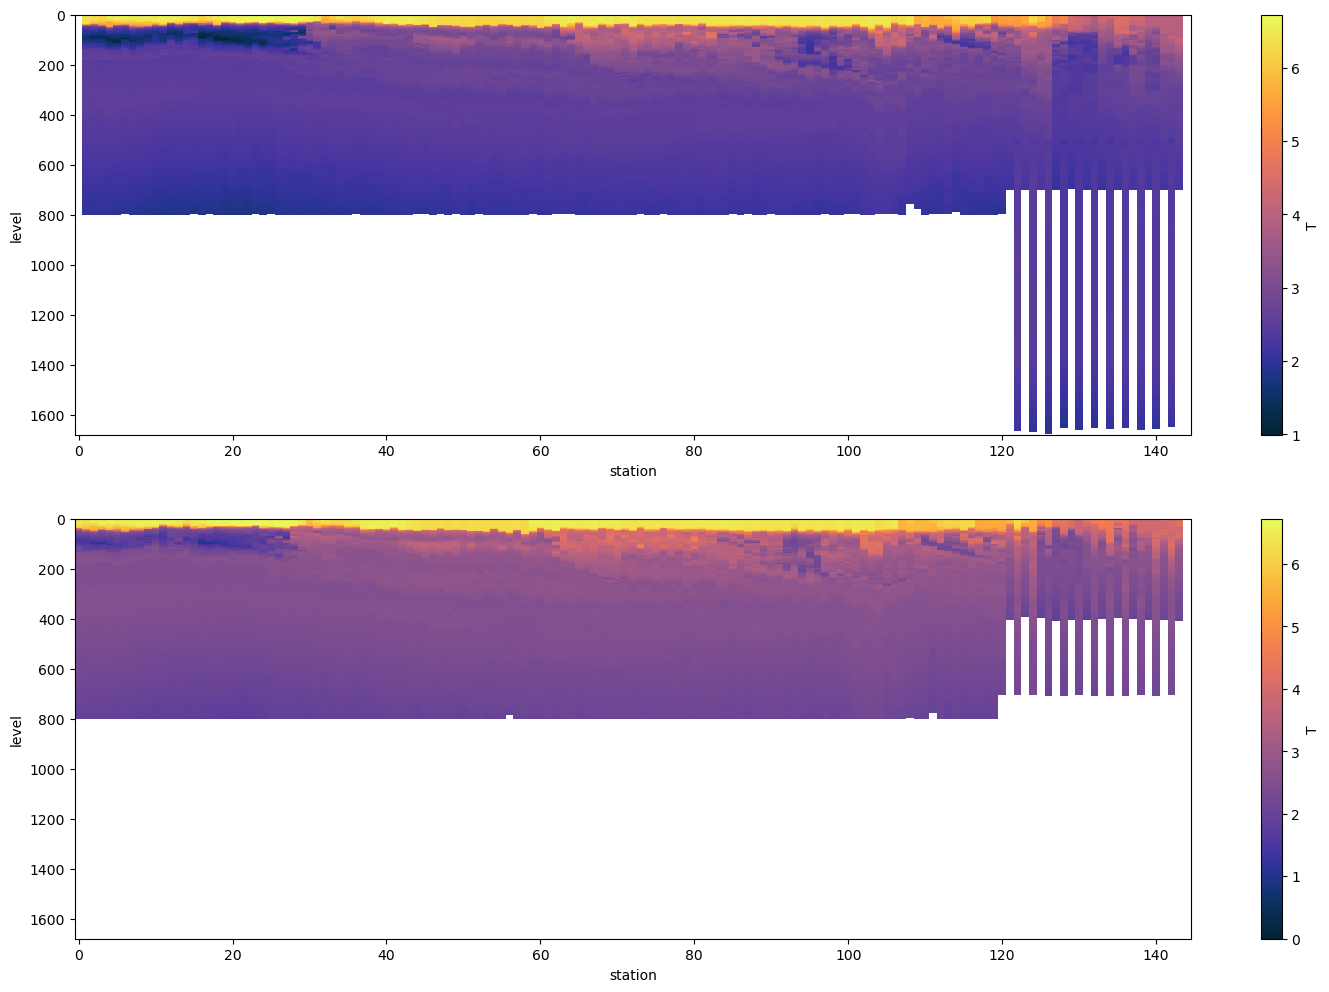

In [11]:
import cmocean as cmo
fig, ax = plt.subplots(nrows=2, figsize=(18,12))

# decents
ctd.isel(profile=slice(0, None, 2)).T.plot(ax=ax[0], x='station', cmap=cmo.cm.thermal)
ax[0].invert_yaxis()

# ascents
ctd.isel(profile=slice(1, None, 2)).T.plot(ax=ax[1], x='station', cmap=cmo.cm.thermal)
ax[1].invert_yaxis()


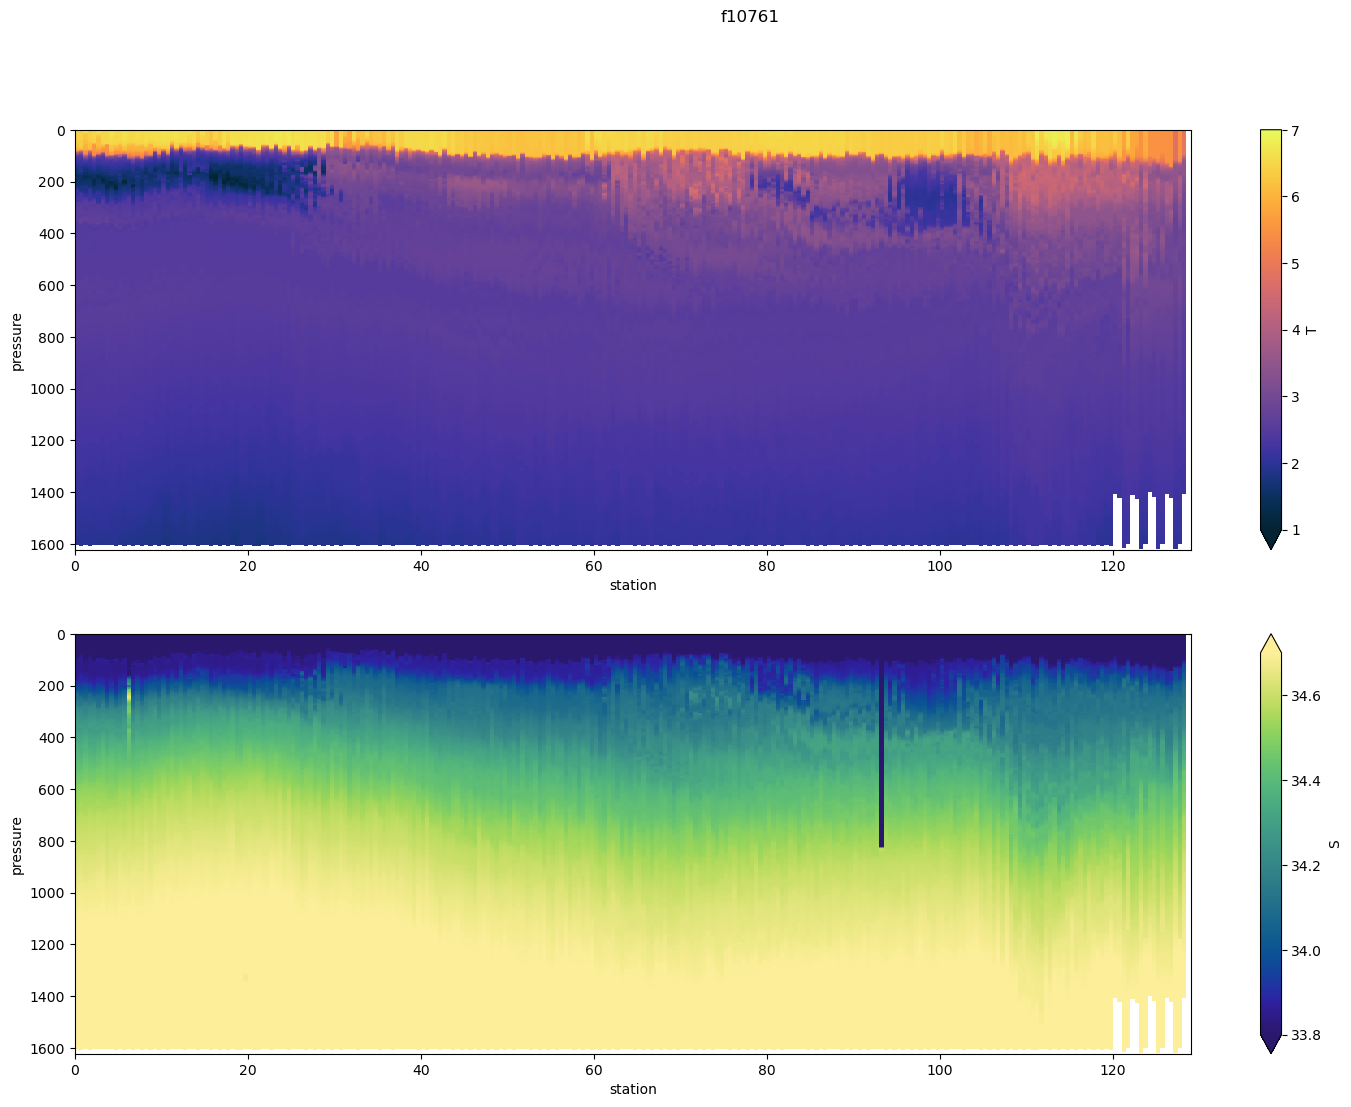

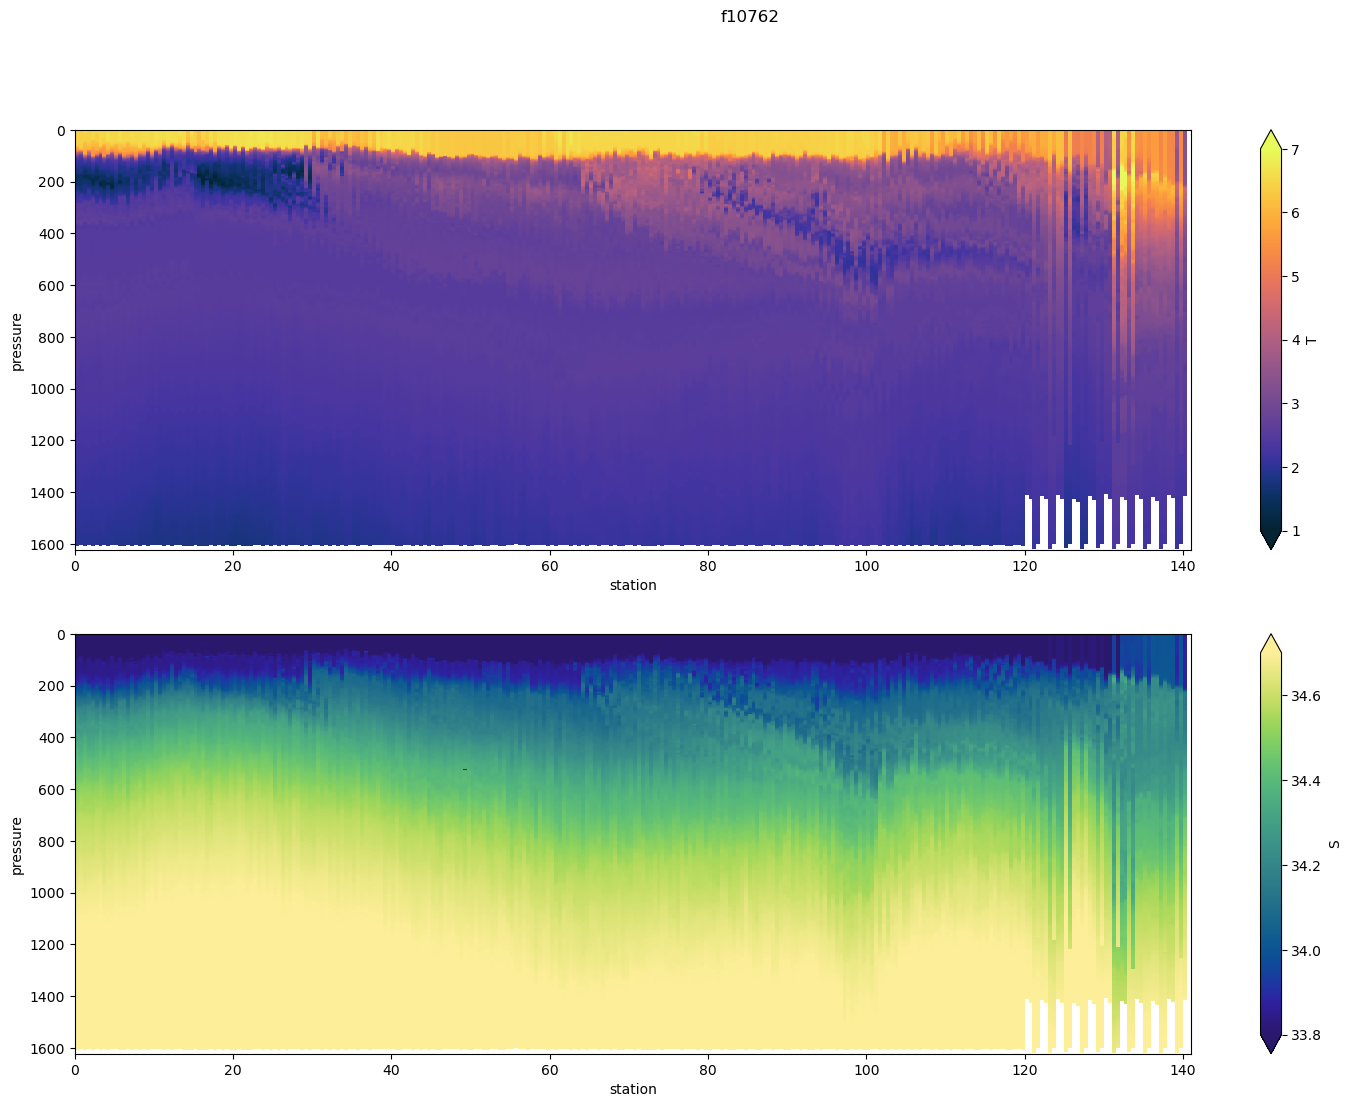

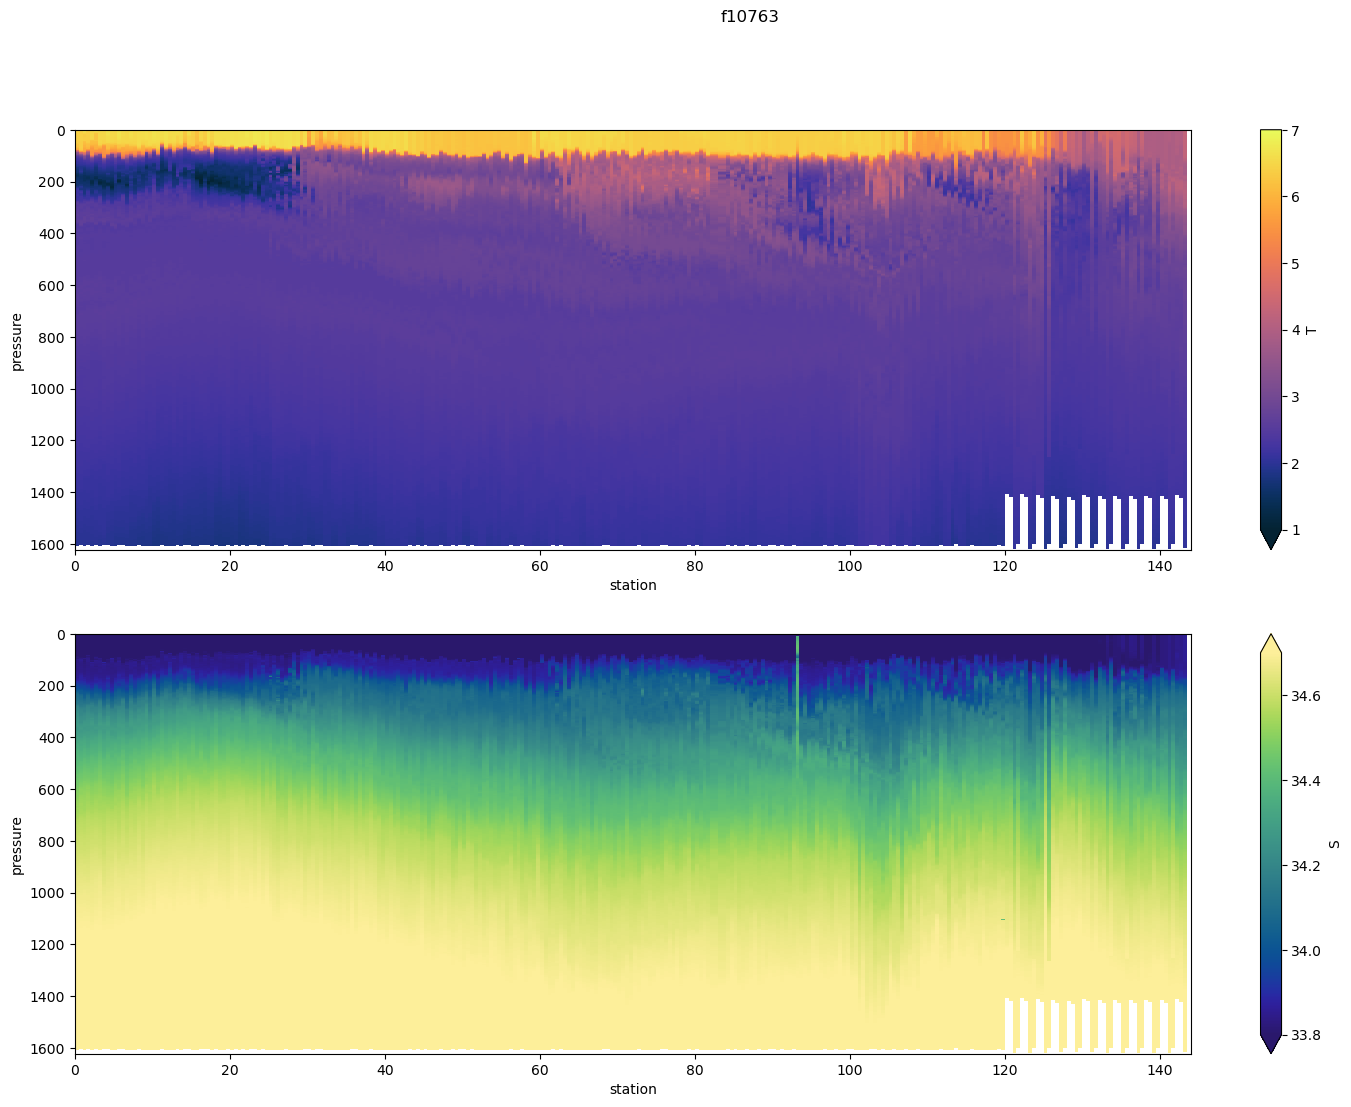

In [14]:
for float_id in float_ids:

    filename = os.path.join(datadir, cruise_id, float_id, 'ctd_data_pgrid.nc')
    ctd = xr.open_dataset(filename)

    fig, ax = plt.subplots(nrows=2, figsize=(18,12))
    
    ctd.T.plot(ax=ax[0], x='station', cmap=cmo.cm.thermal, vmin=1, vmax=7)
    ax[0].invert_yaxis()
    
    ctd.S.plot(ax=ax[1], x='station', vmin=33.8, vmax=34.7, cmap=cmo.cm.haline)
    ax[1].invert_yaxis()

    fig.suptitle(float_id)

    # if savefig:

    fig.savefig(os.path.join(figsdir, '03_temp-sal_on-pgrid_%s.png' %float_id))

In [ ]:
Cf coventions
sea_water_pressure

sea_water_conservative_temperature